Saved: cipn_forest_plot.png / .pdf

Model: random-effects

vs. Placebo/Control: RR=0.55 [0.37, 0.84], P=0.005, I2=66.1%, Q=17.675 (df=6)


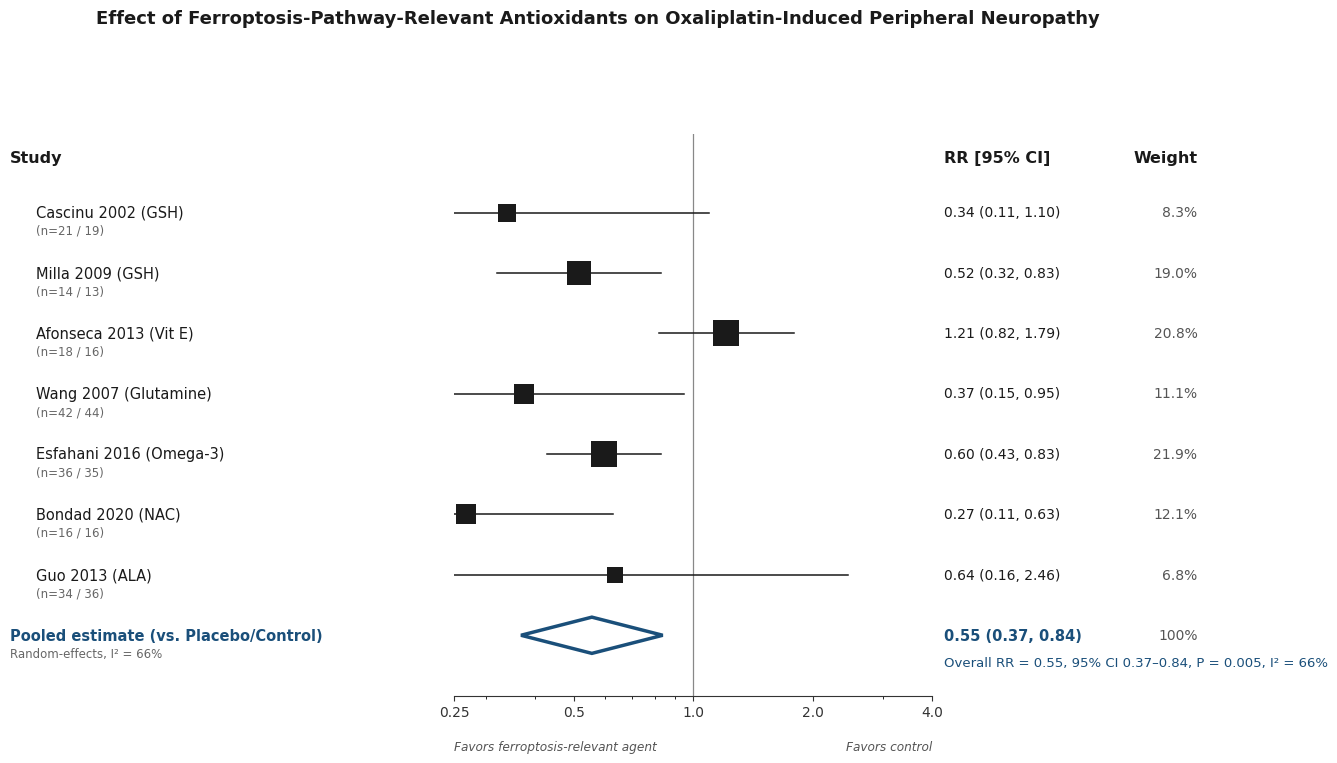

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib as mpl
import os
from scipy.stats import norm # Added for p-value calculation

mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["axes.linewidth"] = 0.8

# ----------------------------------------------------------------------
# 1. DATA
# ----------------------------------------------------------------------

MODEL = "random"   # random-effects, appropriate given cross-study heterogeneity below
NULL_VALUE = 1.0

# REAL DATA — extracted from PubMed-indexed RCTs (oxaliplatin CIPN, ferroptosis-
# pathway-relevant antioxidant/neuroprotective agents vs placebo/no-treatment).
# NOTE: studies use different CIPN severity thresholds (Grade>=2, Grade1-2,
# Grade3-4) -- flagged per-study below. Afonseca/Wang event counts are back-
# calculated from reported percentages (exact n not stated in the source text).
studies = [
    # (Study ID,             subgroup,         n_int, ev_int, n_ctrl, ev_ctrl)
    ("Cascinu 2002 (GSH)",     "vs. Placebo/Control", 21, 3,  19, 8),   # Grade 2-4, cycle 12 (exact counts)
    ("Milla 2009 (GSH)",       "vs. Placebo/Control", 14, 7,  13, 13),  # Grade >=2, cycle 12 (exact counts via review)
    ("Afonseca 2013 (Vit E)",  "vs. Placebo/Control", 18, 15, 16, 11),  # Grade 1-2, cumulative (~from %)
    ("Wang 2007 (Glutamine)",  "vs. Placebo/Control", 42, 5,  44, 14),  # Grade 3-4, cycle 6 (~from %)
    ("Esfahani 2016 (Omega-3)","vs. Placebo/Control", 36, 19, 35, 31),  # Any PN (rTNS-based), exact counts
    ("Bondad 2020 (NAC)",      "vs. Placebo/Control", 16, 4,  16, 15),  # Grade >=2, cycle 8, exact counts
    ("Guo 2013 (ALA)",         "vs. Placebo/Control", 34, 3,  36, 5),   # Grade 3-4 only, n=completers of 243 randomized (71% attrition)
]

# ----------------------------------------------------------------------
# 2. STATISTICS
# ----------------------------------------------------------------------

def study_effect(n_int, ev_int, n_ctrl, ev_ctrl):
    a, b = ev_int, n_int - ev_int
    c, d = ev_ctrl, n_ctrl - ev_ctrl
    if 0 in (a, b, c, d):
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    rr = (a / n_int) / (c / n_ctrl)
    log_rr = np.log(rr)
    se_log_rr = np.sqrt(1 / a - 1 / n_int + 1 / c - 1 / n_ctrl)
    return log_rr, se_log_rr

def pool_subgroup(rows, model="fixed"):
    log_rrs = np.array([r[0] for r in rows])
    ses = np.array([r[1] for r in rows])
    weights_fixed = 1 / ses**2
    pooled_fixed = np.sum(weights_fixed * log_rrs) / np.sum(weights_fixed)
    Q = np.sum(weights_fixed * (log_rrs - pooled_fixed) ** 2)
    df = len(rows) - 1
    I2 = max(0, (Q - df) / Q) * 100 if Q > 0 else 0.0

    if model == "random" and df > 0:
        C = np.sum(weights_fixed) - np.sum(weights_fixed**2) / np.sum(weights_fixed)
        tau2 = max(0, (Q - df) / C) if C > 0 else 0.0
        weights = 1 / (ses**2 + tau2)
    else:
        weights = weights_fixed

    pooled_log_rr = np.sum(weights * log_rrs) / np.sum(weights)
    pooled_se = np.sqrt(1 / np.sum(weights))
    ci_low = pooled_log_rr - 1.96 * pooled_se
    ci_high = pooled_log_rr + 1.96 * pooled_se
    return {
        "rr": np.exp(pooled_log_rr), "ci_low": np.exp(ci_low), "ci_high": np.exp(ci_high),
        "Q": Q, "df": df, "I2": I2, "weights": weights,
        "pooled_log_rr": pooled_log_rr, "pooled_se": pooled_se # Added for p-value calc
    }

computed = []
for sid, grp, n_i, e_i, n_c, e_c in studies:
    log_rr, se = study_effect(n_i, e_i, n_c, e_c)
    rr = np.exp(log_rr)
    ci_l, ci_h = np.exp(log_rr - 1.96 * se), np.exp(log_rr + 1.96 * se)
    computed.append(dict(id=sid, group=grp, n_int=n_i, n_ctrl=n_c,
                          rr=rr, ci_low=ci_l, ci_high=ci_h, log_rr=log_rr, se=se))

subgroups = {}
for grp in ["vs. Placebo/Control"]:
    rows = [(s["log_rr"], s["se"]) for s in computed if s["group"] == grp]
    pooled_result = pool_subgroup(rows, model=MODEL)

    # Calculate p-value for overall effect
    Z = pooled_result["pooled_log_rr"] / pooled_result["pooled_se"]
    p_value = 2 * (1 - norm.cdf(abs(Z)))
    pooled_result["p_value"] = p_value

    subgroups[grp] = pooled_result
    w = subgroups[grp]["weights"]
    wsum = np.sum(w)
    idx = 0
    for s in computed:
        if s["group"] == grp:
            s["weight_pct"] = 100 * w[idx] / wsum
            idx += 1

# ----------------------------------------------------------------------
# 3. BUILD ROW LAYOUT
# ----------------------------------------------------------------------

rows_to_plot = []
for grp in ["vs. Placebo/Control"]:
    for s in computed:
        if s["group"] == grp:
            rows_to_plot.append(("study", s))
    rows_to_plot.append(("summary", grp))

n_rows = len(rows_to_plot)
y_positions = list(range(n_rows, 0, -1))
max_weight = max(s["weight_pct"] for s in computed)

# ----------------------------------------------------------------------
# 4. FIGURE — 3 axes sharing y, dedicated width for each column
# ----------------------------------------------------------------------

# Colors — classic monochrome + single navy accent (matches reference image)
COL_SQUARE = "#1a1a1a"
COL_LINE   = "#1a1a1a"
COL_DIAMOND_EDGE = "#1a4f7a" # Dark blue border for diamond
COL_DIAMOND_FILL = "#ffffff" # White fill for diamond
COL_NULL_LINE = "#888888"
COL_TEXT = "#1a1a1a"
COL_HEADER = "#0d2d4a"

fig, (ax_label, ax_plot, ax_stat) = plt.subplots(
    1, 3, figsize=(12.5, 0.7 * n_rows + 2.2), # Increased vertical spacing
    gridspec_kw={"width_ratios": [2.9, 3.2, 1.7], "wspace": 0.03}
)

for ax in (ax_label, ax_stat):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, n_rows + 1.3)
    ax.axis("off")

ax_plot.set_ylim(0, n_rows + 1.3)

# ---- Column headers ----
ax_label.text(0, n_rows + 0.9, "Study", fontsize=11.5, fontweight="bold", color=COL_TEXT, va="center")
ax_stat.text(0, n_rows + 0.9, "RR [95% CI]", fontsize=11.5, fontweight="bold", color=COL_TEXT, va="center")
ax_stat.text(1.0, n_rows + 0.9, "Weight", fontsize=11.5, fontweight="bold", color=COL_TEXT,
             va="center", ha="right")

for y, (kind, item) in zip(y_positions, rows_to_plot):

    if kind == "header":
        ax_label.text(0, y, item, fontsize=11.5, fontweight="bold", color=COL_HEADER, va="center")

    elif kind == "study":
        s = item
        # --- label column ---
        label = f'{s["id"]}'
        sub_label = f'(n={s["n_int"]} / {s["n_ctrl"]})'
        ax_label.text(0.06, y, label, fontsize=10.5, color=COL_TEXT, va="center") # Study names: 10.5 pt
        ax_label.text(0.06, y - 0.30, sub_label, fontsize=8.5, color="#666666", va="center") # Slightly increased sub-label size

        # --- plot column ---
        ax_plot.plot([s["ci_low"], s["ci_high"]], [y, y], color=COL_LINE, linewidth=1.1, zorder=2)
        size = 55 + 300 * (s["weight_pct"] / max_weight)
        ax_plot.scatter(s["rr"], y, s=size, marker="s", color=COL_SQUARE,
                         edgecolor=COL_SQUARE, linewidth=0, zorder=3)

        # --- stats column ---
        stat_txt = f'{s["rr"]:.2f} ({s["ci_low"]:.2f}, {s["ci_high"]:.2f})'
        ax_stat.text(0, y, stat_txt, fontsize=10, color=COL_TEXT, va="center") # Effect estimates: 10 pt
        ax_stat.text(1.0, y, f'{s["weight_pct"]:.1f}%', fontsize=10, color="#555555", # Effect estimates: 10 pt
                     va="center", ha="right")

    elif kind == "summary":
        pooled = subgroups[item]
        diamond = Polygon([
            (pooled["ci_low"], y),
            (pooled["rr"], y + 0.30),
            (pooled["ci_high"], y),
            (pooled["rr"], y - 0.30),
        ], closed=True, facecolor=COL_DIAMOND_FILL, edgecolor=COL_DIAMOND_EDGE,
           linewidth=2.5, zorder=4) # Increased border thickness for diamond
        ax_plot.add_patch(diamond)

        ax_label.text(0, y, f'Pooled estimate ({item})', fontsize=10.5, fontweight="bold", # Study names: 10.5 pt
                      color=COL_DIAMOND_EDGE, va="center")
        ax_label.text(0, y - 0.30, f'{MODEL.capitalize()}-effects, I² = {pooled["I2"]:.0f}%',
                      fontsize=8.5, color="#666666", va="center") # Slightly increased sub-label size

        stat_txt = f'{pooled["rr"]:.2f} ({pooled["ci_low"]:.2f}, {pooled["ci_high"]:.2f})'
        ax_stat.text(0, y, stat_txt, fontsize=10.5, fontweight="bold", color=COL_DIAMOND_EDGE, va="center") # Effect estimates: 10.5 pt
        ax_stat.text(1.0, y, "100%", fontsize=10, color="#555555", va="center", ha="right") # Effect estimates: 10 pt

        # Add overall statistics below pooled estimate
        overall_stats_text = (f'Overall RR = {pooled["rr"]:.2f}, 95% CI {pooled["ci_low"]:.2f}–{pooled["ci_high"]:.2f}, '
                              f'P = {pooled["p_value"]:.3f}, I² = {pooled["I2"]:.0f}%')
        ax_stat.text(0, y - 0.45, overall_stats_text, fontsize=9.5, color=COL_DIAMOND_EDGE, va="center") # Slightly smaller text for full stats

# ---- null reference line ----
ax_plot.axvline(NULL_VALUE, color=COL_NULL_LINE, linestyle="-", linewidth=0.9, zorder=1)

ax_plot.set_xscale("log")
ax_plot.set_xlim(0.25, 4.0) # Updated x-axis limits
ax_plot.set_xticks([0.25, 0.5, 1.0, 2.0, 4.0]) # Updated x-axis ticks
ax_plot.set_xticklabels(["0.25", "0.5", "1.0", "2.0", "4.0"], fontsize=10) # Updated x-axis tick labels and font size
ax_plot.set_yticks([])
for spine in ["top", "right", "left"]:
    ax_plot.spines[spine].set_visible(False)
ax_plot.spines["bottom"].set_color("#333333")
ax_plot.tick_params(axis="x", colors="#333333")

# Updated positions for "Favors" labels to match new x-axis
ax_plot.text(0.25, -0.9, "Favors ferroptosis-relevant agent", fontsize=8.7,
             color="#555555", ha="left", style="italic")
ax_plot.text(4.0, -0.9, "Favors control", fontsize=8.7,
             color="#555555", ha="right", style="italic")

# Adjusted arrow positions for new x-axis limits
ax_plot.annotate("", xy=(0.95, -0.55), xytext=(0.3, -0.55), # Left arrow
                  arrowprops=dict(arrowstyle="->", color="#888888", lw=0.8))
ax_plot.annotate("", xy=(1.05, -0.55), xytext=(3.5, -0.55), # Right arrow
                  arrowprops=dict(arrowstyle="->", color="#888888", lw=0.8))

# Updated plot title and font size
fig.suptitle(
    "Effect of Ferroptosis-Pathway-Relevant Antioxidants on Oxaliplatin-Induced Peripheral Neuropathy",
    fontsize=13, fontweight="bold", color=COL_TEXT, y=1.02
)

# Removed the footer
# fig.text(0.5, -0.02,
#     "Note: studies use differing CIPN outcome definitions (Cascinu/Milla/Bondad: Grade\u22652; Afonseca: Grade1\u20132; Wang/Guo: Grade3\u20134; Esfahani: any PN via reduced TNS).\n"
#     "Afonseca/Wang event counts back-calculated from %; Milla via secondary review; Guo 2013 reflects only the 29% of 243 randomized patients who completed 24wks (high attrition risk of bias).",
#     fontsize=7.2, color="#777777", ha="center", style="italic")

plt.subplots_adjust(left=0.03, right=0.98, top=0.86, bottom=0.14)

# Create the output directory if it doesn't exist
output_dir = "/mnt/user-data/outputs/"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, "cipn_forest_plot.png"), dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(os.path.join(output_dir, "cipn_forest_plot.pdf"), bbox_inches="tight", facecolor="white")
print("Saved: cipn_forest_plot.png / .pdf")

print(f"\nModel: {MODEL}-effects\n")
for grp, pooled in subgroups.items():
    print(f"{grp}: RR={pooled['rr']:.2f} [{pooled['ci_low']:.2f}, {pooled['ci_high']:.2f}], "
          f"P={pooled['p_value']:.3f}, I2={pooled['I2']:.1f}%, Q={pooled['Q']:.3f} (df={pooled['df']})")